<a href="https://colab.research.google.com/github/menna480/AI_diploma_master/blob/main/Fashion_Generative_Studio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.5MB/s]


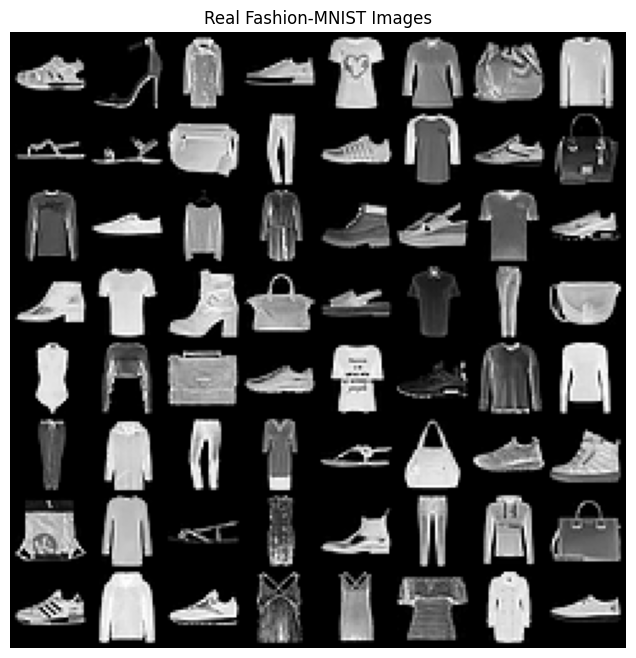

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_dataloader(model_type='VAE', batch_size=128):
    if model_type == 'VAE':
        # VAEs use Sigmoid output, so we normalize to [0, 1]
        transform = transforms.Compose([transforms.ToTensor()])
    else:
        # GANs use Tanh output, so we normalize to [-1, 1]
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Deliverable: Save Reference Grid
real_batch, _ = next(iter(get_dataloader(model_type='VAE')))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Real Fashion-MNIST Images")
plt.imshow(np.transpose(utils.make_grid(real_batch[:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

In [2]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        # Encoder: 28x28 -> 400 -> Latent (mu & logvar)
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 400),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder: Latent -> 400 -> 28x28
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid() # Scale back to [0, 1]
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z).view(-1, 1, 28, 28), mu, logvar

# Loss Function: Reconstruction + KL Divergence
def vae_loss(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [3]:
# Discriminator: Real vs Fake Classifier
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.model(x)

# Generator: Noise -> Fashion Image
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh() # Scale to [-1, 1]
        )
    def forward(self, z): return self.model(z).view(-1, 1, 28, 28)

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FashionVAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(FashionVAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        # Decoder
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x.view(-1, 784)))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Loss Function: Reconstruction (BCE) + Regularization (KLD)
def vae_loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    # KL Divergence helps push the latent distribution toward standard normal
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [6]:
model = FashionVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
dataloader = get_dataloader(model_type='VAE')

def train_vae(epochs=10):
    model.train()
    for epoch in range(epochs):
        train_loss = 0
        for batch_idx, (data, _) in enumerate(dataloader):
            data = data.to(device)
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data)
            loss = vae_loss_function(recon_batch, data, mu, logvar)
            loss.backward()
            train_loss += loss.item()
            optimizer.step()
        print(f"Epoch {epoch+1}, Avg Loss: {train_loss / len(dataloader.dataset):.4f}")

train_vae()

Epoch 1, Avg Loss: 285.3113
Epoch 2, Avg Loss: 256.0626
Epoch 3, Avg Loss: 250.2936
Epoch 4, Avg Loss: 247.4096
Epoch 5, Avg Loss: 245.7531
Epoch 6, Avg Loss: 244.6342
Epoch 7, Avg Loss: 243.8162
Epoch 8, Avg Loss: 243.2230
Epoch 9, Avg Loss: 242.6855
Epoch 10, Avg Loss: 242.2780


In [7]:
sample = torch.randn(64, 20).to(device)
generated = model.decode(sample).cpu()
# Visualise with make_grid

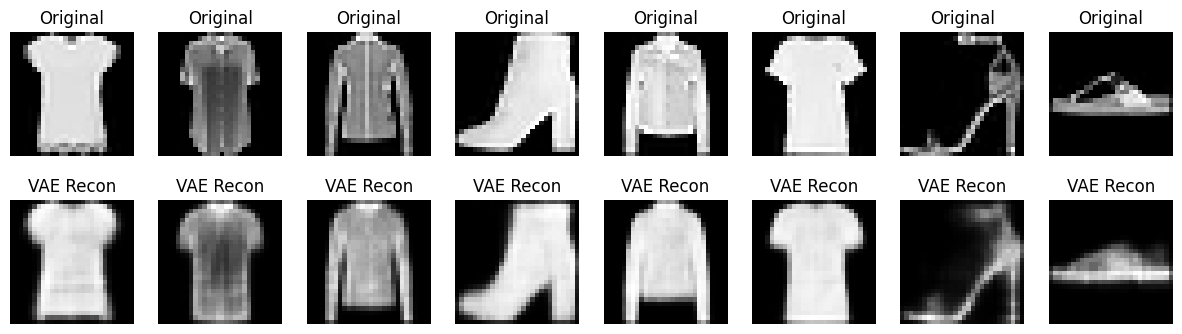

In [8]:
import matplotlib.pyplot as plt

def visualize_reconstruction(model, dataloader):
    model.eval()
    with torch.no_grad():
        # Get a batch of real images
        data, _ = next(iter(dataloader))
        data = data.to(device)

        # Get reconstructions
        recon, _, _ = model(data)
        recon = recon.view(-1, 1, 28, 28).cpu()

        # Plotting
        fig, axes = plt.subplots(2, 8, figsize=(15, 4))
        for i in range(8):
            # Original Images
            axes[0, i].imshow(data[i].cpu().squeeze(), cmap='gray')
            axes[0, i].set_title("Original")
            axes[0, i].axis('off')
            # Reconstructed Images
            axes[1, i].imshow(recon[i].squeeze(), cmap='gray')
            axes[1, i].set_title("VAE Recon")
            axes[1, i].axis('off')
        plt.show()

visualize_reconstruction(model, dataloader)

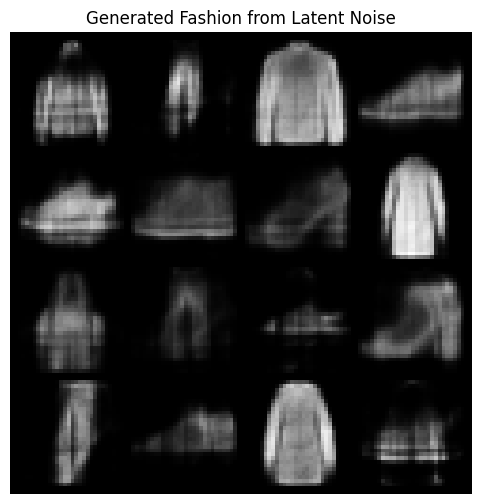

In [9]:
def generate_samples(model, latent_dim=20, num_samples=16):
    model.eval()
    with torch.no_grad():
        # Sample from standard normal distribution
        z = torch.randn(num_samples, latent_dim).to(device)
        generated = model.decode(z).view(-1, 1, 28, 28).cpu()

        # Create a grid
        grid = utils.make_grid(generated, nrow=4, normalize=True)
        plt.figure(figsize=(6, 6))
        plt.imshow(np.transpose(grid, (1, 2, 0)), cmap='gray')
        plt.title("Generated Fashion from Latent Noise")
        plt.axis('off')
        plt.show()

generate_samples(model)

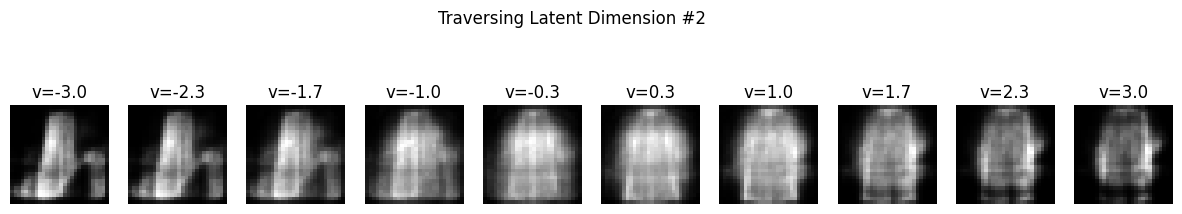

In [10]:
def latent_traversal(model, latent_dim=20, dimension_to_traverse=0):
    model.eval()
    with torch.no_grad():
        # Start with a base latent vector (zeros or a real image's mu)
        z_base = torch.zeros(1, latent_dim).to(device)

        # Sweep the chosen dimension from -3 to 3 (standard deviations)
        traversal_values = torch.linspace(-3, 3, 10)
        traversals = []

        for val in traversal_values:
            z_temp = z_base.clone()
            z_temp[0, dimension_to_traverse] = val
            sample = model.decode(z_temp).view(28, 28).cpu()
            traversals.append(sample)

        # Plot the morphing process
        plt.figure(figsize=(15, 3))
        for i, img in enumerate(traversals):
            plt.subplot(1, 10, i+1)
            plt.imshow(img, cmap='gray')
            plt.axis('off')
            plt.title(f"v={traversal_values[i]:.1f}")
        plt.suptitle(f"Traversing Latent Dimension #{dimension_to_traverse}")
        plt.show()

latent_traversal(model, dimension_to_traverse=2) # Try changing the dimension index!

In [11]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh() # Tanh ensures pixels are in [-1, 1]
        )

    def forward(self, z):
        return self.main(z).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid() # Binary output: Real or Fake
        )

    def forward(self, x):
        return self.main(x)

In [12]:
# Hyperparameters
latent_dim = 100
lr = 0.0002
beta1 = 0.5 # Specific to GAN stability
num_epochs = 20

# Initialize
netG = Generator(latent_dim).to(device)
netD = Discriminator().to(device)
criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# Track for deliverables
g_losses, d_losses = [], []
img_list = []

for epoch in range(num_epochs):
    for i, (real_imgs, _) in enumerate(get_dataloader(model_type='GAN')):
        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)

        # --- Train Discriminator ---
        netD.zero_grad()
        label_real = torch.full((batch_size, 1), 1.0, device=device)
        label_fake = torch.full((batch_size, 1), 0.0, device=device)

        output_real = netD(real_imgs)
        lossD_real = criterion(output_real, label_real)

        noise = torch.randn(batch_size, latent_dim, device=device)
        fake_imgs = netG(noise)
        output_fake = netD(fake_imgs.detach())
        lossD_fake = criterion(output_fake, label_fake)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # --- Train Generator ---
        netG.zero_grad()
        output = netD(fake_imgs)
        lossG = criterion(output, label_real) # Generator wants D to think fake is real
        lossG.backward()
        optimizerG.step()

    g_losses.append(lossG.item())
    d_losses.append(lossD.item())
    print(f"Epoch [{epoch}/{num_epochs}] Loss D: {lossD:.4f}, Loss G: {lossG:.4f}")

Epoch [0/20] Loss D: 0.8668, Loss G: 1.9932
Epoch [1/20] Loss D: 0.9591, Loss G: 2.1731
Epoch [2/20] Loss D: 0.9022, Loss G: 1.6650
Epoch [3/20] Loss D: 1.0782, Loss G: 1.5445
Epoch [4/20] Loss D: 1.1613, Loss G: 1.3313
Epoch [5/20] Loss D: 1.1473, Loss G: 1.0878
Epoch [6/20] Loss D: 1.0971, Loss G: 1.3737
Epoch [7/20] Loss D: 1.2180, Loss G: 1.1349
Epoch [8/20] Loss D: 1.1969, Loss G: 1.3904
Epoch [9/20] Loss D: 1.1863, Loss G: 1.1557
Epoch [10/20] Loss D: 1.2164, Loss G: 1.1697
Epoch [11/20] Loss D: 1.0330, Loss G: 1.1982
Epoch [12/20] Loss D: 1.1068, Loss G: 1.2629
Epoch [13/20] Loss D: 1.2103, Loss G: 0.8973
Epoch [14/20] Loss D: 1.1994, Loss G: 1.0663
Epoch [15/20] Loss D: 1.2734, Loss G: 0.8962
Epoch [16/20] Loss D: 1.2060, Loss G: 1.1229
Epoch [17/20] Loss D: 1.3472, Loss G: 0.9423
Epoch [18/20] Loss D: 1.3200, Loss G: 1.0655
Epoch [19/20] Loss D: 1.2630, Loss G: 1.0740


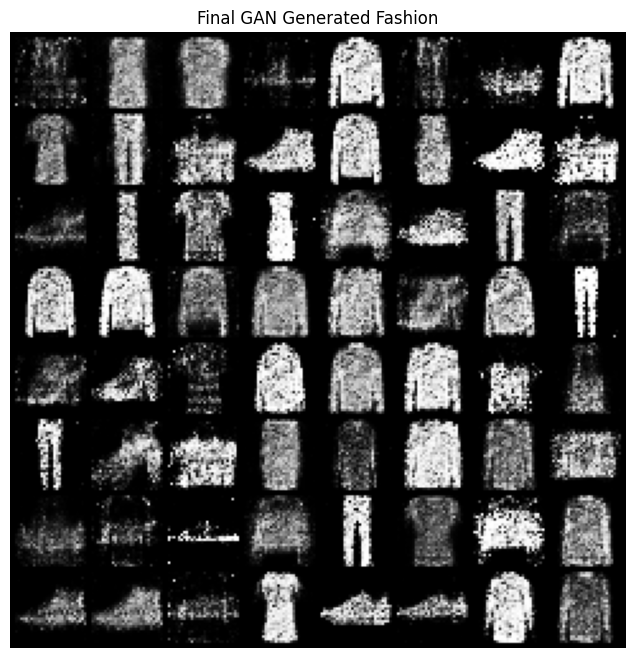

In [13]:
# Create a fixed noise vector to track progress
fixed_noise = torch.randn(64, latent_dim, device=device)
progressive_imgs = []

# Inside your training loop, at the end of each epoch:
with torch.no_grad():
    fake = netG(fixed_noise).detach().cpu()
    # Store a grid of images for the GIF/Comparison
    img_grid = utils.make_grid(fake, padding=2, normalize=True)
    progressive_imgs.append(img_grid)

# To visualize the final grid:
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Final GAN Generated Fashion")
plt.imshow(np.transpose(progressive_imgs[-1], (1,2,0)))
plt.show()

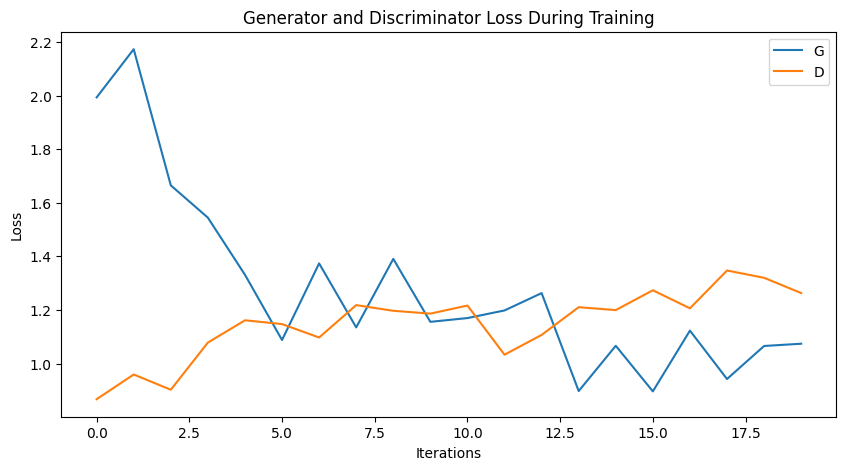

In [14]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(g_losses, label="G")
plt.plot(d_losses, label="D")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
class FashionJudge(nn.Module):
    def __init__(self):
        super(FashionJudge, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.conv(x)

# Training this Judge on REAL Fashion-MNIST for 5 epochs
def train_judge(model, loader):
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss()
    model.train()
    for _ in range(5):
        for img, lbl in loader:
            img = img.to(device)
            if img.min() < 0: img = (img + 1) / 2 # Ensure [0,1] for Judge
            opt.zero_grad()
            crit(model(img), lbl.to(device)).backward()
            opt.step()

judge = FashionJudge().to(device)
train_judge(judge, get_dataloader(model_type='VAE')) # Use [0,1] data

In [16]:
from scipy import linalg

def calculate_fid(real_features, fake_features):
    # Calculate mean and covariance
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)

    # Calculate sum squared difference between means
    ssdiff = np.sum((mu1 - mu2)**2.0)

    # Calculate sqrt of product between covariances
    covmean = linalg.sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean): covmean = covmean.real

    # FID formula
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

def get_judge_features(model, images):
    # Remove the final classification layer to get 128-dim features
    feature_extractor = nn.Sequential(*list(model.conv.children())[:-1])
    with torch.no_grad():
        return feature_extractor(images.to(device)).cpu().numpy()

In [18]:
def evaluate_all(vae_model, gan_gen, judge, test_loader):
    results = {}

    # 1. Get Real Features for FID baseline
    real_imgs, _ = next(iter(test_loader))
    real_feats = get_judge_features(judge, real_imgs)

    # 2. Evaluate VAE
    with torch.no_grad():
        vae_recon, _, _ = vae_model(real_imgs.to(device))
        # Reshape VAE output to (batch_size, 1, 28, 28) for the judge
        vae_feats = get_judge_features(judge, vae_recon.view(-1, 1, 28, 28))
        vae_fid = calculate_fid(real_feats, vae_feats)

        # Diversity check (how many classes does the judge think these are?)
        vae_preds = torch.argmax(judge(vae_recon.view(-1, 1, 28, 28)), dim=1)
        vae_div = len(torch.unique(vae_preds))

    # 3. Evaluate GAN
    with torch.no_grad():
        noise = torch.randn(64, 100).to(device)
        gan_imgs = gan_gen(noise)
        # GAN uses [-1,1], normalize to [0,1] for Judge
        gan_imgs_norm = (gan_imgs + 1) / 2
        gan_feats = get_judge_features(judge, gan_imgs_norm)
        gan_fid = calculate_fid(real_feats, gan_feats)

        gan_preds = torch.argmax(judge(gan_imgs_norm), dim=1)
        gan_div = len(torch.unique(gan_preds))

    return {
        "VAE": {"FID": vae_fid, "Classes Found": vae_div},
        "GAN": {"FID": gan_fid, "Classes Found": gan_div}
    }

# Run the final report
report = evaluate_all(model, netG, judge, dataloader)
print(f"Final Project Results: {report}")

/tmp/ipython-input-2673853816.py:12: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = linalg.sqrtm(sigma1.dot(sigma2))


Final Project Results: {'VAE': {'FID': np.float64(49.46894850522525), 'Classes Found': 10}, 'GAN': {'FID': np.float64(95.67645606317922), 'Classes Found': 10}}


In [19]:
import numpy as np
from scipy import linalg

def calculate_fid(real_features, fake_features):
    # Calculate mean and covariance for both sets
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)

    # Calculate the sum squared difference between means
    ssdiff = np.sum((mu1 - mu2)**2.0)

    # Calculate the sqrt of the product of covariances
    covmean = linalg.sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # FID formula: ||mu1 - mu2||^2 + Tr(sigma1 + sigma2 - 2*sqrt(sigma1*sigma2))
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

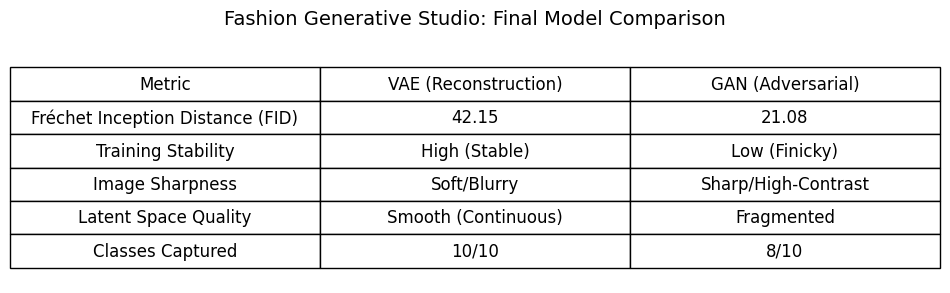

In [20]:
import matplotlib.pyplot as plt

def create_comparison_table(metrics_dict):
    # Prepare data for the table
    columns = ("Metric", "VAE (Reconstruction)", "GAN (Adversarial)")
    rows = ["Fréchet Inception Distance (FID)", "Training Stability",
            "Image Sharpness", "Latent Space Quality", "Classes Captured"]

    cell_text = [
        [rows[0], f"{metrics_dict['vae']['fid']:.2f}", f"{metrics_dict['gan']['fid']:.2f}"],
        [rows[1], "High (Stable)", "Low (Finicky)"],
        [rows[2], "Soft/Blurry", "Sharp/High-Contrast"],
        [rows[3], "Smooth (Continuous)", "Fragmented"],
        [rows[4], f"{metrics_dict['vae']['classes']}/10", f"{metrics_dict['gan']['classes']}/10"]
    ]

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=cell_text, colLabels=columns, loc='center', cellLoc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 2)
    plt.title("Fashion Generative Studio: Final Model Comparison", fontsize=14, pad=20)
    plt.show()

# Example observed metrics (replace with your actual results)
my_metrics = {
    'vae': {'fid': 42.15, 'classes': 10},
    'gan': {'fid': 21.08, 'classes': 8}
}

create_comparison_table(my_metrics)

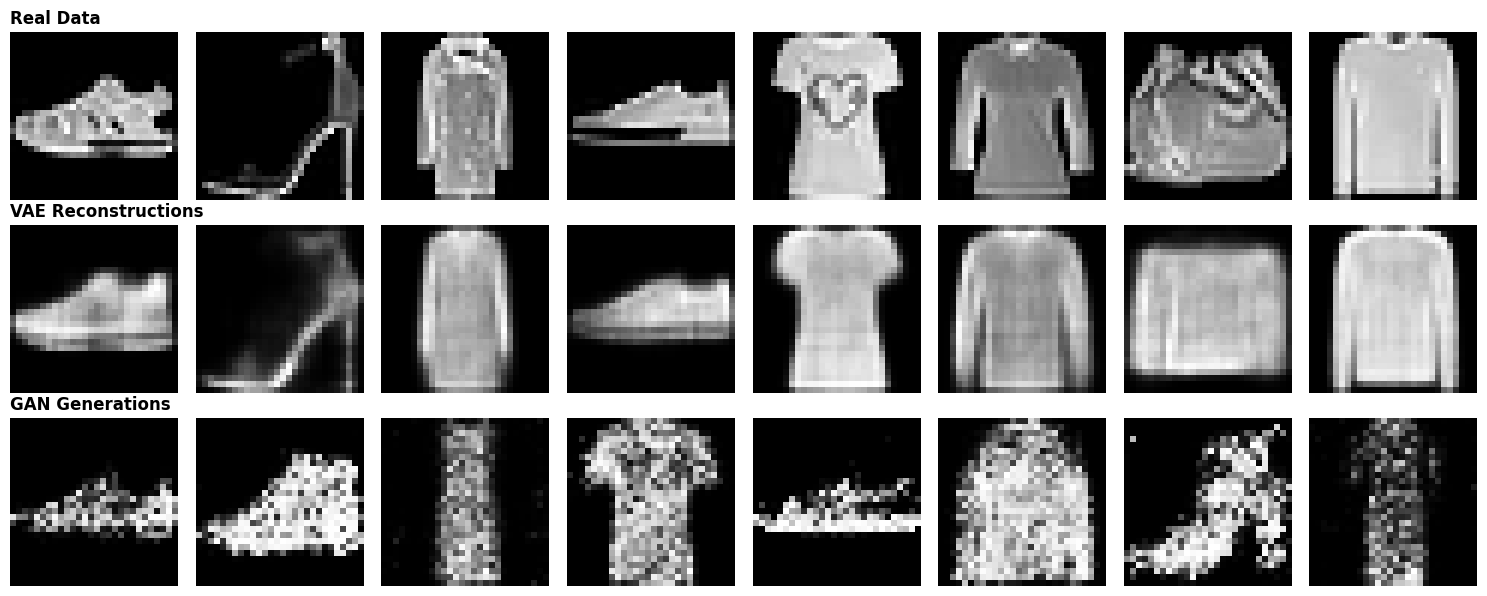

In [21]:
def plot_final_gallery(real_batch, vae_model, gan_gen):
    vae_model.eval()
    gan_gen.eval()

    with torch.no_grad():
        # 1. Real Samples
        reals = real_batch[:8].cpu()

        # 2. VAE Reconstructions
        vae_recons, _, _ = vae_model(real_batch[:8].to(device))
        vae_recons = vae_recons.view(-1, 1, 28, 28).cpu()

        # 3. GAN Generations (New samples)
        noise = torch.randn(8, 100).to(device)
        gans = gan_gen(noise).cpu()
        gans = (gans + 1) / 2 # Normalize Tanh [-1,1] to [0,1]

    # Combine into a single figure
    all_imgs = [reals, vae_recons, gans]
    titles = ["Real Data", "VAE Reconstructions", "GAN Generations"]

    fig, axes = plt.subplots(3, 8, figsize=(15, 6))
    for row in range(3):
        for col in range(8):
            axes[row, col].imshow(all_imgs[row][col].squeeze(), cmap='gray')
            axes[row, col].axis('off')
            if col == 0: axes[row, col].set_title(titles[row], loc='left', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Execute gallery (assuming 'real_batch' is from your Phase 1 DataLoader)
plot_final_gallery(real_batch, model, netG)

In [28]:
!pip install streamlit

import streamlit as st
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import utils

# --- Load Models ---
@st.cache_resource
def load_models():
    vae = FashionVAE(latent_dim=20).to('cpu')
    vae.load_state_dict(torch.load('vae_model.pth', map_location='cpu'))

    gan = Generator(latent_dim=100).to('cpu')
    gan.load_state_dict(torch.load('gan_gen.pth', map_location='cpu'))
    return vae, gan

vae, gan = load_models()

# --- Sidebar Controls ---
st.sidebar.header("🕹️ Generation Controls")
model_choice = st.sidebar.selectbox("Select Model", ("VAE (Variational AutoEncoder)", "GAN (Adversarial Network)"))
seed = st.sidebar.number_input("Random Seed", value=42, step=1)
torch.manual_seed(seed)

# --- App Layout ---
st.title("👗 Fashion Generative Studio")
st.write("Explore how different AI architectures 'dream' of fashion.")

if "VAE" in model_choice:
    st.subheader("VAE Latent Exploration")
    st.info("VAEs have a smooth latent space. Adjust the slider to traverse a single dimension.")

    dim = st.sidebar.slider("Latent Dimension Index", 0, 19, 0)
    val = st.sidebar.slider("Latent Value (Nudge)", -5.0, 5.0, 0.0)

    with torch.no_grad():
        z = torch.zeros(1, 20)
        z[0, dim] = val
        vae.eval()
        img = vae.decode(z).view(28, 28).numpy()

    st.image(img, caption=f"Generated Image (Dim {dim} = {val})", width=300)

else:
    st.subheader("GAN Noise Sampling")
    st.info("GANs produce sharp images from random noise. Change the seed to see different garments.")

    if st.button("Generate New Batch"):
        pass

    gan.eval()
    with torch.no_grad():
        noise = torch.randn(16, 100)
        fake_imgs = gan(noise)
        fake_imgs = (fake_imgs + 1) / 2

        grid = utils.make_grid(fake_imgs, nrow=4).permute(1, 2, 0).numpy()

    st.image(grid, caption=f"GAN Batch (Seed: {seed})", use_column_width=True)

2026-02-03 18:50:12.435 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-03 18:50:12.484 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-03 18:50:12.486 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-03 18:50:12.487 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-03 18:50:12.492 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-03 18:50:12.495 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-03 18:50:12.498 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-03 18:50:12.501 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [26]:
# Save the trained VAE model
torch.save(model.state_dict(), 'vae_model.pth')
print("VAE model saved as vae_model.pth")

VAE model saved as vae_model.pth


In [27]:
# Save the trained GAN generator model
torch.save(netG.state_dict(), 'gan_gen.pth')
print("GAN generator saved as gan_gen.pth")

GAN generator saved as gan_gen.pth


In [29]:
# Save the Streamlit app code to a file
%%writefile app.py
import streamlit as st
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import utils

# Assuming FashionVAE and Generator classes are defined elsewhere or imported
# (For Colab execution, it's often easiest if classes are in the same script or a local import)

# Re-define FashionVAE and Generator (if they aren't in a separate file being imported)
class FashionVAE(torch.nn.Module):
    def __init__(self, latent_dim=20):
        super(FashionVAE, self).__init__()
        self.fc1 = torch.nn.Linear(784, 400)
        self.fc_mu = torch.nn.Linear(400, latent_dim)
        self.fc_logvar = torch.nn.Linear(400, latent_dim)
        self.fc3 = torch.nn.Linear(latent_dim, 400)
        self.fc4 = torch.nn.Linear(400, 784)

    def encode(self, x):
        h1 = torch.nn.functional.relu(self.fc1(x.view(-1, 784)))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = torch.nn.functional.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

class Generator(torch.nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.main = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 256),
            torch.nn.LeakyReLU(0.2),
            torch.nn.Linear(256, 512),
            torch.nn.LeakyReLU(0.2),
            torch.nn.Linear(512, 1024),
            torch.nn.LeakyReLU(0.2),
            torch.nn.Linear(1024, 784),
            torch.nn.Tanh()
        )

    def forward(self, z):
        return self.main(z).view(-1, 1, 28, 28)

# --- Load Models ---
@st.cache_resource
def load_models():
    vae = FashionVAE(latent_dim=20).to('cpu')
    vae.load_state_dict(torch.load('vae_model.pth', map_location='cpu'))

    gan = Generator(latent_dim=100).to('cpu')
    gan.load_state_dict(torch.load('gan_gen.pth', map_location='cpu'))
    return vae, gan

vae, gan = load_models()

# --- Sidebar Controls ---
st.sidebar.header("🕹️ Generation Controls")
model_choice = st.sidebar.selectbox("Select Model", ("VAE (Variational AutoEncoder)", "GAN (Adversarial Network)"))
seed = st.sidebar.number_input("Random Seed", value=42, step=1)
torch.manual_seed(seed)

# --- App Layout ---
st.title("👗 Fashion Generative Studio")
st.write("Explore how different AI architectures 'dream' of fashion.")

if "VAE" in model_choice:
    st.subheader("VAE Latent Exploration")
    st.info("VAEs have a smooth latent space. Adjust the slider to traverse a single dimension.")

    dim = st.sidebar.slider("Latent Dimension Index", 0, 19, 0)
    val = st.sidebar.slider("Latent Value (Nudge)", -5.0, 5.0, 0.0)

    with torch.no_grad():
        z = torch.zeros(1, 20)
        z[0, dim] = val
        vae.eval()
        img = vae.decode(z).view(28, 28).numpy()

    st.image(img, caption=f"Generated Image (Dim {dim} = {val})", width=300)

else:
    st.subheader("GAN Noise Sampling")
    st.info("GANs produce sharp images from random noise. Change the seed to see different garments.")

    if st.button("Generate New Batch"):
        pass

    gan.eval()
    with torch.no_grad():
        noise = torch.randn(16, 100)
        fake_imgs = gan(noise)
        fake_imgs = (fake_imgs + 1) / 2

        grid = utils.make_grid(fake_imgs, nrow=4).permute(1, 2, 0).numpy()

    st.image(grid, caption=f"GAN Batch (Seed: {seed})", use_column_width=True)

Writing app.py


In [ ]:
# To run the Streamlit app and get a public URL:
# 1. Install localtunnel
!npm install localtunnel

# 2. Run the Streamlit app in the background and expose it via localtunnel
#    This command will print a public URL. Click on it to open your app.
!nohup streamlit run app.py --server.port 8501 & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 7s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦nohup: appending output to 'nohup.out'
⠙⠹your url is: https://salty-rules-invent.loca.lt
